In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Сгеннериуем случайные данные
np.random.seed(0) # Установим семяя для воспроизводимости
X = np.random.rand(100, 2) # 100 образцов 2 признака
# Истинные параметры
coefficients = np.array([3, 5])
intercept = 2
# генерируем целевую переменную с добавлением случайнго шума
y = X @ coefficients + intercept + np.random.normal(0, 0.5, 100)

In [4]:
X[:10]

array([[0.5488135 , 0.71518937],
       [0.60276338, 0.54488318],
       [0.4236548 , 0.64589411],
       [0.43758721, 0.891773  ],
       [0.96366276, 0.38344152],
       [0.79172504, 0.52889492],
       [0.56804456, 0.92559664],
       [0.07103606, 0.0871293 ],
       [0.0202184 , 0.83261985],
       [0.77815675, 0.87001215]])

In [5]:
y[:10]

array([7.7857053 , 5.99274029, 5.92670064, 7.55271662, 6.55917965,
       7.98441574, 8.80682728, 2.69253029, 5.61103666, 9.10671248])

In [11]:
# Создадим модель линенйой регрессии и обучим ее
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [12]:
# Выведем параметры модели
print(f"Коэффициекны: {model.coef_}")
print(f"Перехват: {model.intercept_}")

Коэффициекны: [2.78685022 5.01478753]
Перехват: 2.05725162780889


In [13]:
# Сделаем предсказания
y_pred = model.predict(X)

In [14]:
y_pred[:10]

array([7.17323538, 6.46953627, 6.47693584, 7.74879377, 6.66571315,
       6.91596637, 8.28197722, 2.69215341, 6.28900889, 8.58878401])

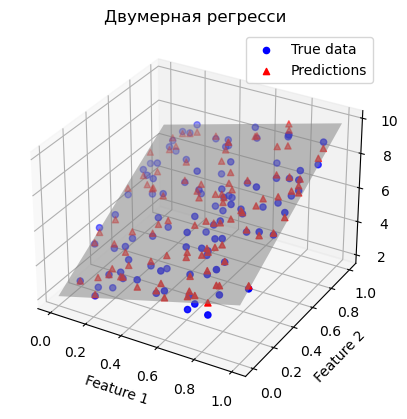

In [18]:
# Визуализируем данные и плоскость регрессии
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Построим настоящие данные
ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='True data')

# Построим предсказанные данные
ax.scatter(X[:, 0], X[:, 1], y_pred, color='red', marker='^', label='Predictions')

#  Построим плоскость регрессии
x0, x1 = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
x2 = model.coef_[0] * x0 + model.coef_[1] * x1 + model.intercept_
ax.plot_surface(x0, x1, x2, alpha=0.5, color='gray', rstride=100, cstride=100)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target')

plt.title('Двумерная регресси')
plt.legend()
plt.show()